In [96]:
import json
from typing import Iterable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

from pandas import MultiIndex, IndexSlice
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")


from config.constants import Constants
C = Constants()

In [97]:
targets = ['language', 'memory', 'executive_function', 'speed']
targets = ['language']
target_cols = ['composite_'+t for t in targets]
tasks = ['cookieTheft', 'picnicScene', 'journaling']

VERSION = "kw19_withoutCohortB"
VERSION = "wavlm_deberta"

FEATURE_SET = "full"
FEATURE_SET = "demographic_node_text_node_audio_task"
FEATURE_SET = "demographic_linguistic_acoustic_task"

if VERSION == 'kw19_withoutCohortB':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw20/20260513_0936_69ea_svr_rbf_wave1_cohortA')
    base_dir_test = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw20/20260513_0936_69ea_svr_rbf_test_on_cohortB')
    base_dirs = [base_dir_cv, base_dir_test]
elif VERSION == 'wavlm_deberta':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw23/20260602_0801_combine_wavlm_deberta_language_v2_zndb')
    base_dirs = [base_dir_cv]
else:
    raise ValueError(f'Unknown VERSION: {VERSION}')

waves_and_ids_path = Path(C.DATA_PROCESSED_COMBINED_2026) / Path('data/waves_and_ids.csv')
print(waves_and_ids_path)

# Cohort definitions: (label, wave_a, wave_b)
COHORTS = [
    ('A', 'wave1', 'wave2'),
    ('B', 'wave2', 'wave3'),
]
ALL_WAVES = ['wave1', 'wave2', 'wave3']

/Users/jheitz/git/luha-prolific-study/data2026/processed_combined/data/waves_and_ids.csv


In [98]:
waves_and_ids = pd.read_csv(waves_and_ids_path, dtype=str).rename(
    columns={'longitudinal_id': 'sample_name_longitudinal', 'study_submission_id': 'sample_name'}
)


def get_longitudinal_participants(waves_and_ids, wave_a, wave_b):
    """Return rows for participants present in BOTH wave_a and wave_b."""
    sub = waves_and_ids[waves_and_ids['wave'].isin([wave_a, wave_b])]
    return sub.groupby('sample_name_longitudinal').filter(
        lambda g: set(g['wave']) == {wave_a, wave_b}
    )


longitudinal_participants_by_cohort = {
    label: get_longitudinal_participants(waves_and_ids, wave_a, wave_b)
    for label, wave_a, wave_b in COHORTS
}

for label, wave_a, wave_b in COHORTS:
    n = longitudinal_participants_by_cohort[label]['sample_name_longitudinal'].nunique()
    print(f'Cohort {label} ({wave_a} - {wave_b}): {n} longitudinal participants')

Cohort A (wave1 - wave2): 305 longitudinal participants
Cohort B (wave2 - wave3): 70 longitudinal participants


In [99]:
def load_prediction_and_target(base_dirs, task, target_col, feature_set):
    """Load prediction_and_target.csv for a given task and target from the results directory."""
    df_base_dirs = []
    for base_dir in base_dirs:
        print(f'Loading target_predictions.csv for task={task}, target={target_col}, base_dir={base_dir}')
        config_path = base_dir / 'config.json'
        if not config_path.exists():
            raise ValueError(f"No config path at {config_path}")
        with open(config_path) as f:
            config = json.load(f)
        if config['target_variable'] != target_col:
            raise ValueError(f"Dir is not for target variable {target_col}")
        subdir = base_dir / feature_set
        df = pd.concat((
            pd.read_csv(
                subdir / 'target_predictions.csv', index_col=None, dtype={'sample_name': str}
            ),
            pd.read_csv(
                subdir / 'target_predictions_full.csv', index_col=None, dtype={'sample_name': str}
            ))).query(f"task == '{task}'").drop(columns=['task'])
        print(f'  Loaded from {base_dir.name}/{subdir.name} - shape: {df.shape}')
        df_with_wave = df.merge(waves_and_ids[['sample_name', 'wave']], on='sample_name', how='left')
        assert df.shape[0] == df_with_wave.shape[0]
        df_base_dirs.append(df_with_wave)
    return pd.concat(df_base_dirs)

## Cross-sectional dataframe (all waves pooled)

In [100]:
target_dfs = []
for target_col, target in zip(target_cols, targets):
    dfs = []
    for task in tasks:
        df = load_prediction_and_target(base_dirs, task, target_col, FEATURE_SET).set_index('sample_name')
        df = df.rename(columns={'prediction': task, target_col: f'target'})
        df = df.drop(columns=['split'])
        df.columns = pd.MultiIndex.from_tuples([(target, c) for c in df.columns])
        dfs.append(df)

    target_df = pd.concat(dfs, axis=1, join='outer')
    #print(target_df.columns)
    #display(target_df)
    duplicated_numerical_columns = target_df.select_dtypes(include='number').columns.duplicated(keep=False)
    if sum(duplicated_numerical_columns) > 0:
        assert target_df.select_dtypes(include='number').loc[:, duplicated_numerical_columns].std(axis=1).max() <= 1e-6, \
            f'Duplicated columns {duplicated_numerical_columns} have different values for target {target}'

    target_df = target_df.loc[:, ~target_df.columns.duplicated()]
    target_df = target_df.dropna()
    # For duplicate wave columns: take the first non-NaN value row-wise across duplicates
    #wave_cols = target_df.xs("wave", axis=1, level=1)
    #wave = wave_cols.bfill(axis=1).iloc[:, 0]
    #target_df = target_df.loc[:,target_df.columns.get_level_values(1) != "wave"]
    #target_df[("language", "wave")] = wave
    #display(target_df)

    target_df = target_df.sort_index(key=lambda idx: pd.Series(idx).apply(lambda s: int(s)))
    target_dfs.append(target_df)

crosssectional = pd.concat(target_dfs, axis=1, join='outer')
crosssectional.to_csv(f"transformed_data/{VERSION}_{FEATURE_SET}_predictions_targets_crosssectional.csv")
crosssectional

Loading target_predictions.csv for task=cookieTheft, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw23/20260602_0801_combine_wavlm_deberta_language_v2_zndb
  Loaded from 20260602_0801_combine_wavlm_deberta_language_v2_zndb/demographic_linguistic_acoustic_task - shape: (1445, 4)
Loading target_predictions.csv for task=picnicScene, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw23/20260602_0801_combine_wavlm_deberta_language_v2_zndb
  Loaded from 20260602_0801_combine_wavlm_deberta_language_v2_zndb/demographic_linguistic_acoustic_task - shape: (1454, 4)
Loading target_predictions.csv for task=journaling, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw23/20260602_0801_combine_wavlm_deberta_language_v2_zndb
  Loaded from 20260602_0801_combine_wavlm_deberta_language_v2_zndb/demographic_linguistic_acoustic_ta

language                                          
               target cookieTheft   wave picnicScene journaling
sample_name                                                    
83           0.127514   -0.006010  wave1   -0.267840   0.197700
84           1.591000   -0.263089  wave1    0.105450   0.002772
85          -0.137563    0.242262  wave1    0.276016   0.246718
86           0.084998    0.594175  wave1    0.788894   0.811260
88           0.123648    0.434443  wave1    0.625572   0.735143
...               ...         ...    ...         ...        ...
1946         1.059569    0.741888  wave3    0.978571   0.769884
1947         1.380432    0.488211  wave3    0.238341   0.373149
1949        -0.021867    0.134981  wave3   -0.443148   0.035601
1950         0.536164    0.275453  wave3   -0.109867   0.000766
1951         1.568476    0.707348  wave3    0.624265   0.944900

[1432 rows x 5 columns]

## Longitudinal dataframes per cohort

In [101]:
def build_longitudinal(crosssectional, longitudinal_participants, wave_a, wave_b):
    """Build a wide longitudinal df indexed by sample_name_longitudinal,
    with columns (wave, target, col) for the two cohort waves."""
    waves = [wave_a, wave_b]
    longitudinal_dfs = []
    for wave in waves:
        lp_wave = longitudinal_participants[longitudinal_participants['wave'] == wave][
            ['sample_name_longitudinal', 'sample_name']
        ]
        lp_wave.columns = pd.MultiIndex.from_tuples([(c, '') for c in lp_wave.columns])
        df = crosssectional.merge(
            lp_wave, left_index=True, right_on='sample_name', how='inner'
        ).set_index('sample_name_longitudinal')
        # Sanity check: every row should be from the requested wave
        # (works as long as at least one target column exists in crosssectional)
        any_target = targets[0]
        print(df[(any_target, 'wave')].value_counts())
        print(wave)
        print((df[(any_target, 'wave')] == wave).value_counts())
        print(df[df[(any_target, 'wave')] != wave])
        assert np.all(df[(any_target, 'wave')] == wave), (
            f'Mismatched wave column when building longitudinal for {wave}'
        )
        df = df.drop(columns=['sample_name'], level=0)
        df.columns = pd.MultiIndex.from_tuples([(wave, target, col) for target, col in df.columns])
        longitudinal_dfs.append(df)

    return pd.concat(longitudinal_dfs, axis=1, join='outer').sort_index()


longitudinal_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    long_df = build_longitudinal(
        crosssectional,
        longitudinal_participants_by_cohort[label],
        wave_a, wave_b,
    )
    long_df.to_csv(
        f"transformed_data/{VERSION}_{FEATURE_SET}_predictions_targets_longitudinal_cohort{label}.csv"
    )
    longitudinal_by_cohort[label] = long_df
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}): longitudinal shape = {long_df.shape}')

longitudinal_by_cohort['A']

(language, wave)
wave1    289
Name: count, dtype: int64
wave1
(language, wave)
True    289
Name: count, dtype: int64
Empty DataFrame
Columns: [(language, target), (language, cookieTheft), (language, wave), (language, picnicScene), (language, journaling), (sample_name, )]
Index: []
(language, wave)
wave2    295
Name: count, dtype: int64
wave2
(language, wave)
True    295
Name: count, dtype: int64
Empty DataFrame
Columns: [(language, target), (language, cookieTheft), (language, wave), (language, picnicScene), (language, journaling), (sample_name, )]
Index: []
Cohort A (wave1 ↔ wave2): longitudinal shape = (305, 10)
(language, wave)
wave2    70
Name: count, dtype: int64
wave2
(language, wave)
True    70
Name: count, dtype: int64
Empty DataFrame
Columns: [(language, target), (language, cookieTheft), (language, wave), (language, picnicScene), (language, journaling), (sample_name, )]
Index: []
(language, wave)
wave3    69
Name: count, dtype: int64
wave3
(language, wave)
True    69
Name: coun

wave1                                            \
                          language                                             
                            target cookieTheft   wave picnicScene journaling   
sample_name_longitudinal                                                       
01d1fdfc3a               -0.092677   -0.078487  wave1    0.249503   0.301303   
0367083668                1.124401    0.485050  wave1    0.325914  -0.011802   
048eb2a01e                0.894593    0.649629  wave1    0.756952   1.057351   
049af4901b                0.983548   -0.243929  wave1   -0.414294   0.041686   
04d9f72ef8                0.588701   -0.106552  wave1   -0.318040  -0.634867   
...                            ...         ...    ...         ...        ...   
fb5094f9be                1.115175    0.306507  wave1    0.135921  -0.051520   
fbc2d6f448                0.632690    0.448764  wave1    0.373423   0.119231   
fbdafd951f                0.513217   -0.148320  wave1   -0.521209  -0.023493   
feccc75c1f               -0.324149    0.423964  wave1    1.147208   1.017750   
ff30c563d8               -1.011262    0.118518  wave1   -0.081252  -0.249630   

                             wave2                                            
                          language                                            
                            target cookieTheft   wave picnicScene journaling  
sample_name_longitudinal                                                      
01d1fdfc3a               -0.688462   -0.428008  wave2    0.006293  -0.036078  
0367083668                2.241093    0.320958  wave2   -0.094453   0.578866  
048eb2a01e                0.317482    0.233801  wave2    0.361893   0.617694  
049af4901b                0.834917   -0.057945  wave2   -0.892645   0.096970  
04d9f72ef8               -0.148855   -0.327520  wave2   -0.137888  -0.236866  
...                            ...         ...    ...         ...        ...  
fb5094f9be                0.749528    0.013220  wave2    0.280059   0.177823  
fbc2d6f448                1.204556    0.544564  wave2    0.257618   0.661552  
fbdafd951f                0.973508    0.062165  wave2   -0.293248   0.490064  
feccc75c1f               -0.484027    0.843404  wave2    0.843888   0.546468  
ff30c563d8               -1.636732    0.119770  wave2    0.006078   0.016198  

[305 rows x 10 columns]

In [102]:
longitudinal_by_cohort['B']


wave2                                            \
                          language                                             
                            target cookieTheft   wave picnicScene journaling   
sample_name_longitudinal                                                       
0058189c15                0.006779    0.241500  wave2    0.248471   0.517431   
022d83ae48                0.357727   -0.473766  wave2   -0.217045  -0.431632   
03d72dddc0               -0.410754    0.339056  wave2    0.171253   0.329183   
0504985b92                0.090453    0.014370  wave2   -0.054582   0.291126   
06fe3daa84                0.795783    0.785228  wave2    0.792398   0.532643   
...                            ...         ...    ...         ...        ...   
ecf60a2c3c               -1.665199    0.016126  wave2   -0.436828  -0.147680   
f06cfb4a31                0.530192    0.682268  wave2    0.668988   0.290589   
f0d5f9966a               -0.154648   -0.341878  wave2   -0.300078  -0.078184   
f5404e6a44                0.147582    0.229209  wave2    0.349113  -0.086072   
fd2e093359                2.298303    1.162636  wave2    1.322075   1.170580   

                             wave3                                            
                          language                                            
                            target cookieTheft   wave picnicScene journaling  
sample_name_longitudinal                                                      
0058189c15                0.170084    0.172251  wave3    0.239474   0.386870  
022d83ae48                1.681084   -0.170193  wave3   -0.059128   0.003583  
03d72dddc0                0.310234    0.367999  wave3    0.275787   0.407066  
0504985b92               -0.228062    0.244320  wave3   -0.168044   0.551166  
06fe3daa84                1.322928    0.893408  wave3    0.852750   0.790953  
...                            ...         ...    ...         ...        ...  
ecf60a2c3c               -1.053530    0.374711  wave3    0.001740   0.264977  
f06cfb4a31                0.259218    0.482264  wave3    0.725640   0.044974  
f0d5f9966a               -0.021867    0.134981  wave3   -0.443148   0.035601  
f5404e6a44               -0.485001    0.173342  wave3   -0.072994   0.043953  
fd2e093359                2.510695    1.378336  wave3    1.262992   1.179697  

[70 rows x 10 columns]

## Paired scatter plots: predictions across waves

A cookieTheft language
A picnicScene language
A journaling language


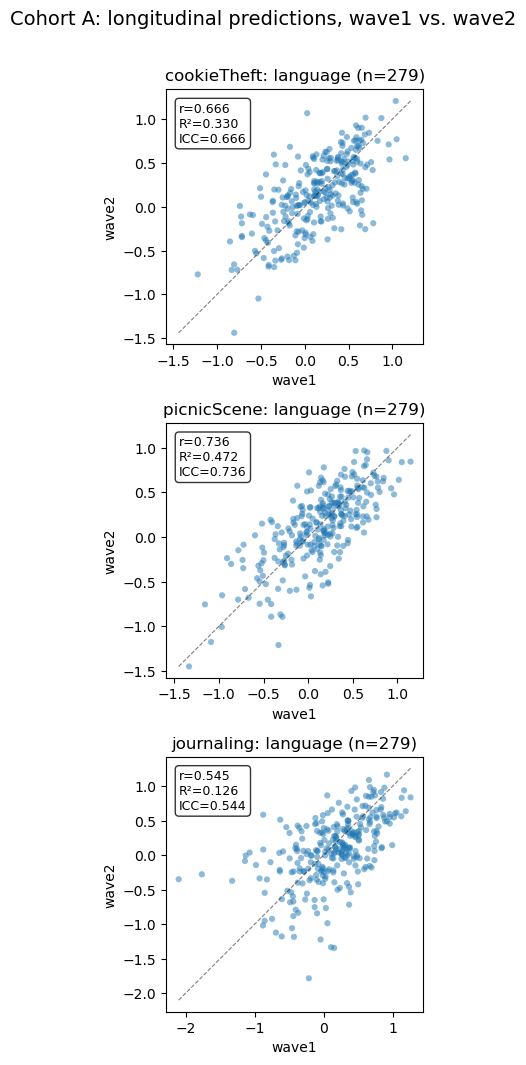

B cookieTheft language
B picnicScene language
B journaling language


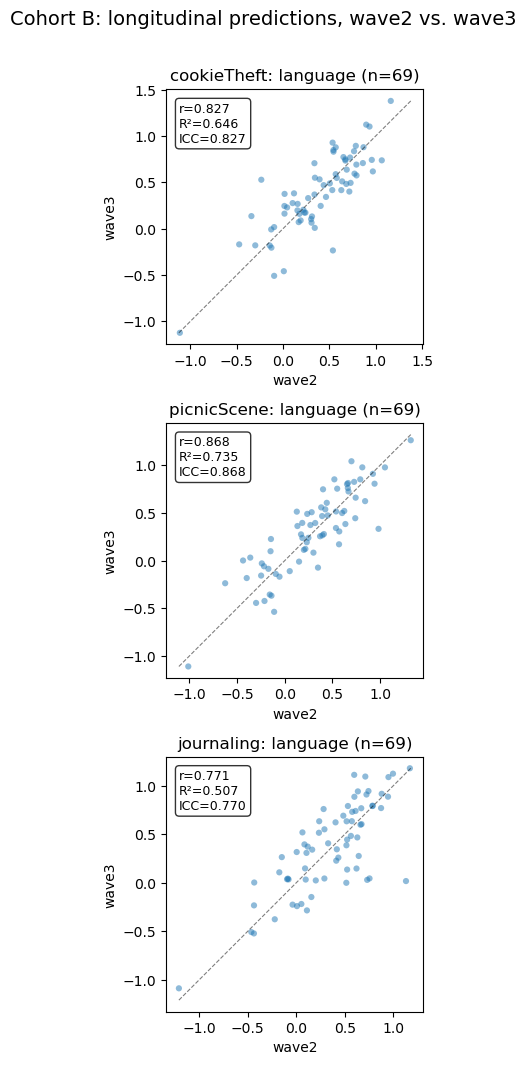

In [103]:
def compute_icc(df, val_1_col, val_2_col, id_col):
    """Compute ICC3 between two repeated measures."""
    df_melted = df.reset_index().melt(
        id_vars=[id_col],
        value_vars=[val_1_col, val_2_col],
        var_name='wave',
        value_name='score',
    )
    df_melted.columns = ['id', 'wave', 'score']
    icc = pg.intraclass_corr(
        data=df_melted, targets='id', raters='wave',
        ratings='score', nan_policy='omit',
    )
    return icc[icc['Type'] == 'ICC3'].iloc[0]['ICC']


def plot_paired_scatter(longitudinal, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        len(tasks), len(targets),
        figsize=(3.5 * len(targets), 3.5 * len(tasks)),
    )
    for row_idx, task in enumerate(tasks):
        for col_idx, target in enumerate(targets):
            print(label, task, target)
            if len(targets) > 1:
                ax = axes[row_idx, col_idx]
            else:
                ax = axes[row_idx] if len(tasks) > 1 else axes

            val_1_col = (wave_a, target, task)
            val_2_col = (wave_b, target, task)
            df_here = longitudinal.loc[:, [val_1_col, val_2_col]].copy().dropna()
            x, y = df_here.loc[:, val_1_col], df_here.loc[:, val_2_col]
            r_val, _ = pearsonr(x, y)
            r2_val = r2_score(x, y)
            icc_val = compute_icc(
                df_here,
                val_1_col=val_1_col, val_2_col=val_2_col,
                id_col=('sample_name_longitudinal', '', ''),
            )

            ax.scatter(x, y, alpha=0.5, s=20, edgecolors='none')
            lims = [min(x.min(), y.min()), max(x.max(), y.max())]
            ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
            ax.set_xlabel(wave_a)
            ax.set_ylabel(wave_b)
            ax.set_title(f'{task}: {target} (n={len(df_here)})')
            ax.text(
                0.05, 0.95,
                f'r={r_val:.3f}\nR\u00b2={r2_val:.3f}\nICC={icc_val:.3f}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            )
            ax.set_aspect('equal', adjustable='datalim')

    fig.suptitle(
        f'Cohort {label}: longitudinal predictions, {wave_a} vs. {wave_b}',
        fontsize=14, y=1.01,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_paired_scatter(longitudinal_by_cohort[label], label, wave_a, wave_b, targets, tasks)

## Prediction performance: R² and MSE

Pooled metrics use the cross-sectional dataframe and appear once. Per-cohort longitudinal subsets are stacked into the same `eval_df` with a `cohort` column.

In [104]:


def rename_target(target):
    if target == 'language':
        return 'Language'
    elif target == 'executive_function':
        return 'Executive Function'
    elif target == 'memory':
        return 'Memory'
    elif target == 'speed':
        return 'Speed'
    return target.replace('_', ' ').title()


rename_tasks = {
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling',
        'average_prediction': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
    }
def rename_task(task):
    return rename_tasks.get(task, task.replace('_', ' ').title())

def bootstrap_metric(y_true, y_pred, metric_func, n_boot=1000, seed=0):
    """Return (point_estimate, ci_low, ci_high) via paired bootstrap over samples."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    point = metric_func(y_true, y_pred)
    rng_local = np.random.default_rng(seed)
    n = len(y_true)
    boot_vals = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng_local.integers(0, n, size=n)
        boot_vals[i] = metric_func(y_true[idx], y_pred[idx])
    ci_low, ci_high = np.percentile(boot_vals, [2.5, 97.5])
    return point, ci_low, ci_high


def _metrics_row(y_true, y_pred, cohort, subset, target, task, n_boot, seed):
    r2, r2_lo, r2_hi = bootstrap_metric(y_true, y_pred, r2_score, n_boot=n_boot, seed=seed)
    mse, mse_lo, mse_hi = bootstrap_metric(y_true, y_pred, mean_squared_error, n_boot=n_boot, seed=seed)
    n = len(y_true)
    denominator_r2 = np.sum(np.square(y_true - np.mean(y_true)))
    numerator_r2 = np.sum(np.square(y_true - y_pred))
    y_var = np.var(y_true)
    assert np.abs(n*y_var - denominator_r2) < 0.001, \
        f"n*y_var={n*y_var:.3f} vs denominator_r2={denominator_r2:.3f}"
    r2_alt = 1 - numerator_r2/denominator_r2
    assert np.abs(r2_alt - r2) < 0.001, f"r2_alt={r2_alt:.3f} vs r2={r2:.3f}"
    assert np.abs(1 - (mse / y_var) - r2) < 0.001, \
        f"mse/y_var={mse/y_var:.3f} vs r2={r2:.3f}"
    return {
        'cohort': cohort, 'subset': subset, 'target': target, 'task': task,
        'n': n, 'y_var': y_var,
        'r2': r2, 'r2_ci_low': r2_lo, 'r2_ci_high': r2_hi,
        'mse': mse, 'mse_ci_low': mse_lo, 'mse_ci_high': mse_hi,
    }


def _add_pooled_rows(rows, crosssectional, targets, tasks, n_boot, seed):
    for target in targets:
        y_true = crosssectional[(target, 'target')]
        for task in tasks:
            rows.append(_metrics_row(
                y_true, crosssectional[(target, task)],
                cohort='-', subset='pooled', target=target, task=task,
                n_boot=n_boot, seed=seed,
            ))
        pred_avg = crosssectional.loc[:, [(target, t) for t in tasks]].mean(axis=1)
        rows.append(_metrics_row(
            y_true, pred_avg,
            cohort='-', subset='pooled', target=target, task='average',
            n_boot=n_boot, seed=seed,
        ))
        pred_pictureDescription = crosssectional.loc[
            :, [(target, t) for t in ['cookieTheft', 'picnicScene']]
        ].mean(axis=1)
        rows.append(_metrics_row(
            y_true, pred_pictureDescription,
            cohort='-', subset='pooled', target=target, task='pictureDescription',
            n_boot=n_boot, seed=seed,
        ))


def _add_cohort_rows_old(rows, longitudinal, cohort, wave_a, wave_b, targets, tasks, n_boot, seed):
    for wave in [wave_a, wave_b]:
        for target in targets:
            y_true = longitudinal[(wave, target, 'target')]
            for task in tasks:
                rows.append(_metrics_row(
                    y_true, longitudinal[(wave, target, task)],
                    cohort=cohort, subset=f'{wave}_longitudinal',
                    target=target, task=task,
                    n_boot=n_boot, seed=seed,
                ))
            pred_avg = longitudinal.loc[:, [(wave, target, t) for t in tasks]].mean(axis=1)
            rows.append(_metrics_row(
                y_true, pred_avg,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='average',
                n_boot=n_boot, seed=seed,
            ))
            pred_pictureDescription = longitudinal.loc[
                :, [(wave, target, t) for t in ['picnicScene', 'cookieTheft']]
            ].mean(axis=1)
            rows.append(_metrics_row(
                y_true, pred_pictureDescription,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='pictureDescription',
                n_boot=n_boot, seed=seed,
            ))


def _add_cohort_rows(rows, longitudinal, cohort, wave_a, wave_b, targets, tasks, n_boot, seed):
    for target in targets:
        for task in tasks:
            wave_rows = []
            for wave in [wave_a, wave_b]:
                y_true = longitudinal[(wave, target, 'target')]
                row = _metrics_row(
                    y_true, longitudinal[(wave, target, task)],
                    cohort=cohort, subset=f'{wave}_longitudinal',
                    target=target, task=task,
                    n_boot=n_boot, seed=seed,
                )
                wave_rows.append(row)
                rows.append(row)
            rows.append({
                'cohort': cohort, 'subset': 'mean_wave', 'target': target, 'task': task,
                **pd.DataFrame(wave_rows)[['n','y_var','r2','r2_ci_low', 'r2_ci_high', 'mse', 'mse_ci_low', 'mse_ci_high']].mean(axis=0).to_dict(),
            })


        wave_rows = []
        for wave in [wave_a, wave_b]:
            y_true = longitudinal[(wave, target, 'target')]
            pred_avg = longitudinal.loc[:, [(wave, target, t) for t in tasks]].mean(axis=1)
            row = _metrics_row(
                y_true, pred_avg,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='average',
                n_boot=n_boot, seed=seed,
            )
            wave_rows.append(row)
            rows.append(row)
        rows.append({
            'cohort': cohort, 'subset': 'mean_wave', 'target': target, 'task': 'average',
            **pd.DataFrame(wave_rows)[['n','y_var','r2','r2_ci_low', 'r2_ci_high', 'mse', 'mse_ci_low', 'mse_ci_high']].mean(axis=0).to_dict(),
        })

        wave_rows = []
        for wave in [wave_a, wave_b]:
            y_true = longitudinal[(wave, target, 'target')]
            pred_pictureDescription = longitudinal.loc[
                :, [(wave, target, t) for t in ['picnicScene', 'cookieTheft']]
            ].mean(axis=1)
            row = _metrics_row(
                y_true, pred_pictureDescription,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='pictureDescription',
                n_boot=n_boot, seed=seed,
            )
            wave_rows.append(row)
            rows.append(row)
        rows.append({
            'cohort': cohort, 'subset': 'mean_wave', 'target': target, 'task': 'pictureDescription',
            **pd.DataFrame(wave_rows)[['n','y_var','r2','r2_ci_low', 'r2_ci_high', 'mse', 'mse_ci_low', 'mse_ci_high']].mean(axis=0).to_dict(),
        })




def build_eval_df(crosssectional, longitudinal_by_cohort, cohorts, targets, tasks,
                  n_boot=1000, seed=0):
    """Long-format dataframe of R2 and MSE.

    Pooled rows appear once (cohort='-'). Per-cohort longitudinal rows are
    stacked with a `cohort` column.
    """
    rows = []
    _add_pooled_rows(rows, crosssectional, targets, tasks, n_boot, seed)
    for label, wave_a, wave_b in cohorts:
        _add_cohort_rows(
            rows, longitudinal_by_cohort[label].dropna(), label,
            wave_a, wave_b, targets, tasks, n_boot, seed,
        )
    return pd.DataFrame(rows)

In [105]:
eval_df = build_eval_df(
    crosssectional, longitudinal_by_cohort, COHORTS, targets, tasks,
    n_boot=1000, seed=0,
)
eval_df

,cohort,subset,target,task,n,y_var,r2,r2_ci_low,r2_ci_high,mse,mse_ci_low,mse_ci_high
0,-,pooled,language,cookieTheft,1432.0,0.992808,0.259224,0.214701,0.299007,0.735449,0.673531,0.799710
1,-,pooled,language,picnicScene,1432.0,0.992808,0.268629,0.230133,0.307284,0.726111,0.664133,0.787977
2,-,pooled,language,journaling,1432.0,0.992808,0.238690,0.193846,0.280231,0.755834,0.698145,0.819476
3,-,pooled,language,average,1432.0,0.992808,0.301367,0.264729,0.336442,0.693608,0.636822,0.754566
4,-,pooled,language,pictureDescription,1432.0,0.992808,0.285342,0.246626,0.322607,0.709519,0.647488,0.771501
5,A,wave1_longitudinal,language,cookieTheft,279.0,0.857537,0.168876,0.080094,0.250463,0.712720,0.594698,0.859853
6,A,wave2_longitudinal,language,cookieTheft,279.0,0.886961,0.200579,0.103688,0.277415,0.709055,0.601786,0.821404
7,A,mean_wave,language,cookieTheft,279.0,0.872249,0.184728,0.091891,0.263939,0.710887,0.598242,0.840629
8,A,wave1_longitudinal,language,picnicScene,279.0,0.857537,0.173981,0.096336,0.242823,0.708342,0.591754,0.849882
9,A,wave2_longitudinal,language,picnicScene,279.0,0.886961,0.223475,0.119275,0.302273,0.688747,0.588620,0.809975


In [106]:
# Wide views: tasks (incl. 'average', 'pictureDescription') as columns.
# Each cell is "<metric> [ci_low, ci_high]" formatted to 2 decimals.
def make_wide(eval_df, metric):
    df = eval_df.copy()
    df[f'{metric}_str'] = df.apply(
        lambda r: f"{r[metric]:.2f} [{r[f'{metric}_ci_low']:.2f}, {r[f'{metric}_ci_high']:.2f}]",
        axis=1,
    )
    index_cols = ['cohort', 'subset', 'target', 'n']
    if metric == 'r2' or True:
        index_cols.append('y_var')
    wide = df.pivot_table(
        index=index_cols, columns='task', values=f'{metric}_str', aggfunc='first',
    ).loc[:, tasks + ['average']]   # ['average', 'pictureDescription']
    wide.columns.name = None
    return wide


eval_wide_r2 = make_wide(eval_df, 'r2')
eval_wide_mse = make_wide(eval_df, 'mse')
eval_wide_r2

cookieTheft  \
cohort subset             target   n      y_var                         
-      pooled             language 1432.0 0.992808  0.26 [0.21, 0.30]   
A      mean_wave          language 279.0  0.872249  0.18 [0.09, 0.26]   
       wave1_longitudinal language 279.0  0.857537  0.17 [0.08, 0.25]   
       wave2_longitudinal language 279.0  0.886961  0.20 [0.10, 0.28]   
B      mean_wave          language 69.0   0.894724  0.27 [0.09, 0.42]   
       wave2_longitudinal language 69.0   0.858433  0.29 [0.14, 0.42]   
       wave3_longitudinal language 69.0   0.931015  0.25 [0.05, 0.41]   

                                                          picnicScene  \
cohort subset             target   n      y_var                         
-      pooled             language 1432.0 0.992808  0.27 [0.23, 0.31]   
A      mean_wave          language 279.0  0.872249  0.20 [0.11, 0.27]   
       wave1_longitudinal language 279.0  0.857537  0.17 [0.10, 0.24]   
       wave2_longitudinal language 279.0  0.886961  0.22 [0.12, 0.30]   
B      mean_wave          language 69.0   0.894724  0.29 [0.08, 0.43]   
       wave2_longitudinal language 69.0   0.858433  0.30 [0.11, 0.45]   
       wave3_longitudinal language 69.0   0.931015  0.27 [0.06, 0.42]   

                                                            journaling  \
cohort subset             target   n      y_var                          
-      pooled             language 1432.0 0.992808   0.24 [0.19, 0.28]   
A      mean_wave          language 279.0  0.872249   0.13 [0.01, 0.22]   
       wave1_longitudinal language 279.0  0.857537  0.08 [-0.05, 0.18]   
       wave2_longitudinal language 279.0  0.886961   0.18 [0.07, 0.27]   
B      mean_wave          language 69.0   0.894724   0.24 [0.04, 0.38]   
       wave2_longitudinal language 69.0   0.858433   0.31 [0.13, 0.43]   
       wave3_longitudinal language 69.0   0.931015  0.18 [-0.06, 0.34]   

                                                              average  
cohort subset             target   n      y_var                        
-      pooled             language 1432.0 0.992808  0.30 [0.26, 0.34]  
A      mean_wave          language 279.0  0.872249  0.23 [0.15, 0.29]  
       wave1_longitudinal language 279.0  0.857537  0.20 [0.12, 0.27]  
       wave2_longitudinal language 279.0  0.886961  0.25 [0.17, 0.32]  
B      mean_wave          language 69.0   0.894724  0.30 [0.12, 0.42]  
       wave2_longitudinal language 69.0   0.858433  0.33 [0.18, 0.44]  
       wave3_longitudinal language 69.0   0.931015  0.26 [0.06, 0.41]

In [107]:
rename_cols = {
        'subset': 'Assessment',
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling', 'target': 'Composite Score',
        'average': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
        'y_var': '$\\Var(y)$',
    }

for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Regression results Cohort {label}, R^2, full table ({now()}) ===')
    visible = eval_wide_r2.query("cohort == @label").query("subset == 'mean_wave'")
    n = visible.reset_index()['n'].iloc[0]
    visible = visible.reset_index(level=[0,1], drop=True).reset_index(drop=False).drop(columns=['n']).set_index('target')
    order = {
        'language': 1,
        'memory': 2,
        'executive_function': 3
    }
    visible = visible.sort_index(key=lambda idx: idx.map(lambda x: order.get(x, 4)))
    visible = visible.reset_index(drop=False)
    visible['target'] = visible['target'].apply(lambda t: rename_target(t))
    visible = visible[['target', 'journaling', 'cookieTheft', 'picnicScene', 'average', 'y_var']]
    visible.columns = [rename_cols.get(c, c) for c in visible.columns]
    caption = f"Cohort {label} ($n={int(n)}$) regression performance: Average $R^2$ of the prediction model across baseline and follow-up waves for all composite score targets. We report point estimates with 95\\% bootstrap CI. Complementary MSE results are reported in Supplementary Table~\\ref{{tab:regression_cohortA_mean_wave}}"
    latex = visible.to_latex(
            float_format='%.2f',
            column_format='l' + 'c' * (visible.shape[1] - 1),
            index=False,
            caption=caption,
            label=f"tab:r2_cohort{label}_all_targets_mean_wave",
            escape=False,
            na_rep='',
        )
    print(latex)



% === Regression results Cohort A, R^2, full table (2026-06-02 13:13) ===
\begin{table}
\caption{Cohort A ($n=279$) regression performance: Average $R^2$ of the prediction model across baseline and follow-up waves for all composite score targets. We report point estimates with 95\% bootstrap CI. Complementary MSE results are reported in Supplementary Table~\ref{tab:regression_cohortA_mean_wave}}
\label{tab:r2_cohortA_all_targets_mean_wave}
\begin{tabular}{lccccc}
\toprule
Composite Score & Journaling & Cookie Theft & Picnic Scene & Avg. Prediction & $\Var(y)$ \\
\midrule
Language & 0.13 [0.01, 0.22] & 0.18 [0.09, 0.26] & 0.20 [0.11, 0.27] & 0.23 [0.15, 0.29] & 0.87 \\
\bottomrule
\end{tabular}
\end{table}


% === Regression results Cohort B, R^2, full table (2026-06-02 13:13) ===
\begin{table}
\caption{Cohort B ($n=69$) regression performance: Average $R^2$ of the prediction model across baseline and follow-up waves for all composite score targets. We report point estimates with 95\% 

In [108]:
eval_wide_mse

cookieTheft  \
cohort subset             target   n      y_var                         
-      pooled             language 1432.0 0.992808  0.74 [0.67, 0.80]   
A      mean_wave          language 279.0  0.872249  0.71 [0.60, 0.84]   
       wave1_longitudinal language 279.0  0.857537  0.71 [0.59, 0.86]   
       wave2_longitudinal language 279.0  0.886961  0.71 [0.60, 0.82]   
B      mean_wave          language 69.0   0.894724  0.65 [0.40, 0.95]   
       wave2_longitudinal language 69.0   0.858433  0.61 [0.34, 0.91]   
       wave3_longitudinal language 69.0   0.931015  0.70 [0.47, 0.99]   

                                                          picnicScene  \
cohort subset             target   n      y_var                         
-      pooled             language 1432.0 0.992808  0.73 [0.66, 0.79]   
A      mean_wave          language 279.0  0.872249  0.70 [0.59, 0.83]   
       wave1_longitudinal language 279.0  0.857537  0.71 [0.59, 0.85]   
       wave2_longitudinal language 279.0  0.886961  0.69 [0.59, 0.81]   
B      mean_wave          language 69.0   0.894724  0.64 [0.40, 0.93]   
       wave2_longitudinal language 69.0   0.858433  0.60 [0.35, 0.90]   
       wave3_longitudinal language 69.0   0.931015  0.68 [0.45, 0.95]   

                                                           journaling  \
cohort subset             target   n      y_var                         
-      pooled             language 1432.0 0.992808  0.76 [0.70, 0.82]   
A      mean_wave          language 279.0  0.872249  0.76 [0.64, 0.89]   
       wave1_longitudinal language 279.0  0.857537  0.79 [0.67, 0.94]   
       wave2_longitudinal language 279.0  0.886961  0.73 [0.62, 0.84]   
B      mean_wave          language 69.0   0.894724  0.68 [0.44, 0.97]   
       wave2_longitudinal language 69.0   0.858433  0.59 [0.35, 0.85]   
       wave3_longitudinal language 69.0   0.931015  0.77 [0.53, 1.08]   

                                                              average  
cohort subset             target   n      y_var                        
-      pooled             language 1432.0 0.992808  0.69 [0.64, 0.75]  
A      mean_wave          language 279.0  0.872249  0.68 [0.57, 0.79]  
       wave1_longitudinal language 279.0  0.857537  0.69 [0.58, 0.82]  
       wave2_longitudinal language 279.0  0.886961  0.66 [0.56, 0.77]  
B      mean_wave          language 69.0   0.894724  0.63 [0.40, 0.91]  
       wave2_longitudinal language 69.0   0.858433  0.57 [0.33, 0.86]  
       wave3_longitudinal language 69.0   0.931015  0.69 [0.47, 0.97]

In [109]:
def render_subset_label(subset, wave_a, wave_b):
    if subset == 'pooled':
        return 'All data'
    if subset == f'{wave_a}_longitudinal':
        return f'{wave_a.replace("wave", "Wave ")}'
    if subset == f'{wave_b}_longitudinal':
        return f'{wave_b.replace("wave", "Wave ")}'
    return subset




### LaTeX tables (one per cohort, all metrics and  targets)

In [110]:
def emit_full_table(eval_wide_r2, eval_wide_mse, label, wave_a, wave_b, targets,
                    target_filter=None, keep_var_y=True):
    """One table per cohort, both metrics, only longitudinal subsets.

    Rows ordered: (target, metric, subset). Within each target, the two R^2
    rows (Baseline, Follow-up) come first, then the two MSE rows. The Metric
    column is shown once per (target, metric) pair via \\multirow.

    If target_filter is set, only that target is shown and no target header
    rows are emitted.
    """
    if target_filter is not None:
        targets_to_use = [target_filter]
    else:
        targets_to_use = list(targets)

    subset_rename = {
        f'{wave_a}_longitudinal': 'Baseline',
        f'{wave_b}_longitudinal': 'Follow-up',
    }
    subset_order = {'Baseline': 0, 'Follow-up': 1, 'Mean': 0}
    metric_order = {'$R^2$': 0, 'MSE': 1}

    def prep(wide, metric_name):
        df = wide.reset_index()
        df = df[(df['target'].isin(targets_to_use)) & (df['cohort'] == label)].copy()
        df = df[df['subset'].isin(subset_rename)]
        df['subset'] = df['subset'].map(subset_rename)
        df['Metric'] = metric_name
        return df.drop(columns=['cohort'])

    table = pd.concat(
        [prep(eval_wide_r2, '$R^2$'), prep(eval_wide_mse, 'MSE')],
        ignore_index=True,
    )

    table['_t'] = table['target'].apply(lambda t: targets_to_use.index(t))
    table['_m'] = table['Metric'].map(metric_order)
    table['_s'] = table['subset'].map(subset_order)
    table = table.sort_values(['_t', '_m', '_s']).drop(columns=['_t', '_m', '_s'])
    table = table.reset_index(drop=True)

    # Pull the single n value for the caption (constant across rows in this cohort
    # thanks to the both-waves filter); assert that assumption.
    n_values = table['n'].dropna().unique()
    assert len(n_values) == 1, f'Expected one n per cohort, got {n_values}'
    n_value = int(n_values[0])

    rename_cols = {
        'subset': 'Assessment',
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling',
        'average': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
        'y_var': '$\\Var(y)$',
    }
    table = table.rename(columns=rename_cols)
    # n is no longer shown
    table = table.drop(columns=['n'])


    is_first_in_metric_block = (table['Assessment'] == 'Baseline')
    is_second_in_metric_block = (table['Assessment'] == 'Follow-up')
    table.loc[is_first_in_metric_block, 'Metric'] = (
        table.loc[is_first_in_metric_block, 'Metric'].apply(
            lambda v: f'\\multirow{{2}}{{*}}{{{v}}}'
        )
    )
    table.loc[is_second_in_metric_block, 'Metric'] = ''

    target_per_row = table['target'].tolist()
    metric_per_row = table['Metric'].tolist()
    visible = table.drop(columns=['target'])

    test_cols = [
        c for c in ['Cookie Theft', 'Picnic Scene', 'Journaling',
                    'Avg. Picture Desc.', 'Avg. Prediction']
        if c in visible.columns
    ]

    # Column order: Metric, Assessment, tasks, Var(y)
    if keep_var_y:
        col_order = ['Metric', 'Assessment'] + test_cols + ['$\\Var(y)$']
    else:
        col_order = ['Metric', 'Assessment'] + test_cols
    visible = visible[[c for c in col_order if c in visible.columns]]

    r2_var_y_note = "Note that the variance in true scores ($\\Var(y)$) contributes to the $R^2$ calculation, with lower $\\Var(y)$ producing lower $R^2$ values given identical errors. " if keep_var_y else ""
    if target_filter is not None:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance for the \\textit{{{rename_target(target_filter)}}} composite score: $R^2$ and MSE of the prediction model on the Baseline and Follow-up longitudinal splits. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}_{target_filter}'
    else:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance: $R^2$ and MSE of the prediction model on the Baseline and Follow-up longitudinal splits for all composite score targets. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}'

    n_cols = len(visible.columns)
    # Metric (c), Assessment (l), tasks + Var(y) (c)
    latex = visible.to_latex(
        float_format='%.2f',
        column_format='cl' + 'c' * (n_cols - 2),
        index=False,
        caption=caption,
        label=tex_label,
        escape=False,
        na_rep='',
    )

    lines = latex.splitlines()
    try:
        body_start = next(i for i, ln in enumerate(lines)
                          if ln.strip() == '\\midrule') + 1
        body_end = next(i for i, ln in enumerate(lines)
                        if ln.strip() == '\\bottomrule')
    except StopIteration:
        print(latex)
        return

    data_lines = lines[body_start:body_end]
    assert len(data_lines) == len(target_per_row)

    new_body = []
    prev_target = None
    for i, (tgt, row) in enumerate(zip(target_per_row, data_lines)):
        if target_filter is None and tgt != prev_target:
            if prev_target is not None:
                new_body.append('\\midrule')
            new_body.append(
                f'\\multicolumn{{{n_cols}}}{{c}}{{\\textit{{{rename_target(tgt)}}}}} \\\\'
            )
        prev_target = tgt
        new_body.append(row)
        is_last = (i == len(data_lines) - 1)
        next_is_same_target = (
            not is_last and target_per_row[i + 1] == tgt
        )
        if (metric_per_row[i] == '$R^2$'
                and next_is_same_target
                and metric_per_row[i + 1] == 'MSE'):
            new_body.append('\\addlinespace')

    print('\n'.join(lines[:body_start] + new_body + lines[body_end:]))


for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Regression results Cohort {label}, full table ({now()}) ===')
    emit_full_table(eval_wide_r2, eval_wide_mse, label, wave_a, wave_b, targets)

    #print(f'\n% === Regression results Cohort {label}, language target only  ({now()}) ===')
    #emit_full_table(eval_wide_r2, eval_wide_mse, label, wave_a, wave_b, targets,
    #                target_filter='language', keep_var_y=False)




% === Regression results Cohort A, full table (2026-06-02 13:13) ===
\begin{table}
\caption{Cohort A ($n=279$) regression performance: $R^2$ and MSE of the prediction model on the Baseline and Follow-up longitudinal splits for all composite score targets. We report point estimates with 95\% bootstrap CI. Note that the variance in true scores ($\Var(y)$) contributes to the $R^2$ calculation, with lower $\Var(y)$ producing lower $R^2$ values given identical errors. }
\label{tab:regression_cohortA}
\begin{tabular}{clccccc}
\toprule
Metric & Assessment & Cookie Theft & Picnic Scene & Journaling & Avg. Prediction & $\Var(y)$ \\
\midrule
\multicolumn{7}{c}{\textit{Language}} \\
\multirow{2}{*}{$R^2$} & Baseline & 0.17 [0.08, 0.25] & 0.17 [0.10, 0.24] & 0.08 [-0.05, 0.18] & 0.20 [0.12, 0.27] & 0.86 \\
 & Follow-up & 0.20 [0.10, 0.28] & 0.22 [0.12, 0.30] & 0.18 [0.07, 0.27] & 0.25 [0.17, 0.32] & 0.89 \\
\multirow{2}{*}{MSE} & Baseline & 0.71 [0.59, 0.86] & 0.71 [0.59, 0.85] & 0.79 [0.67, 0.94

In [111]:
def emit_full_table_mean_wave(eval_wide_r2, eval_wide_mse, label, wave_a, wave_b, targets,
                    target_filter=None, keep_var_y=True):
    """One table per cohort, both metrics, mean_wave subset only.

    Rows ordered: (metric, target). Each metric gets a \\multicolumn block
    header. Within each block, one row per target showing the mean_wave value.

    If target_filter is set, only that target is shown and no target header
    rows are emitted (but metric block headers are still shown).
    """
    if target_filter is not None:
        targets_to_use = [target_filter]
    else:
        targets_to_use = list(targets)

    metric_order = {'$R^2$': 0, 'MSE': 1}

    def prep(wide, metric_name):
        df = wide.reset_index()
        df = df[(df['target'].isin(targets_to_use)) & (df['cohort'] == label)].copy()
        df = df[df['subset'] == 'mean_wave']
        df['Metric'] = metric_name
        return df.drop(columns=['cohort', 'subset'])

    table = pd.concat(
        [prep(eval_wide_r2, '$R^2$'), prep(eval_wide_mse, 'MSE')],
        ignore_index=True,
    )

    table['_t'] = table['target'].apply(lambda t: targets_to_use.index(t))
    table['_m'] = table['Metric'].map(metric_order)
    table = table.sort_values(['_m', '_t']).drop(columns=['_t', '_m'])
    table = table.reset_index(drop=True)

    n_values = table['n'].dropna().unique()
    assert len(n_values) == 1, f'Expected one n per cohort, got {n_values}'
    n_value = int(n_values[0])

    rename_cols = {
        'target': 'Target',
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling',
        'average': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
        'y_var': '$\\Var(y)$',
    }
    table = table.rename(columns=rename_cols)
    table = table.drop(columns=['n'])

    table['Target'] = table['Target'].apply(rename_target)


    target_per_row = table['Target'].tolist()
    metric_per_row = table['Metric'].tolist()
    visible = table#.drop(columns=['Metric'])

    visible['Metric'] = np.where(visible['Metric'].shift() != visible['Metric'], visible['Metric'], '')
    visible['Metric'] = visible['Metric'].apply(
        #lambda v: f'\\multirow{{2}}{{*}}{{{v}}}' if v != '' else v
        lambda v: f"\\parbox[t]{{2mm}}{{\\multirow{{3}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{v}}}}}}}" if v != '' else v
    )

    test_cols = [
        c for c in ['Cookie Theft', 'Picnic Scene', 'Journaling',
                    'Avg. Picture Desc.', 'Avg. Prediction']
        if c in visible.columns
    ]

    if keep_var_y:
        col_order = ['Metric', 'Target'] + test_cols + ['$\\Var(y)$']
    else:
        col_order = ['Metric', 'Target'] + test_cols
    visible = visible[[c for c in col_order if c in visible.columns]]

    visible = visible.rename(columns={'Metric': ''})

    r2_var_y_note = "Note that the variance in true scores ($\\Var(y)$) contributes to the $R^2$ calculation, with lower $\\Var(y)$ producing lower $R^2$ values given identical errors. " if keep_var_y else ""
    if target_filter is not None:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance for the \\textit{{{rename_target(target_filter)}}} composite score: $R^2$ and MSE of the prediction model on the mean over assessment waves. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}_{target_filter}'
    else:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance: $R^2$ and MSE of the prediction model (mean over both assessments) for all composite score targets. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}_mean_wave'

    n_cols = len(visible.columns)
    # Target (l), tasks + Var(y) (c)
    latex = visible.to_latex(
        float_format='%.2f',
        column_format='ll' + 'c' * (n_cols - 2),
        index=False,
        caption=caption,
        label=tex_label,
        escape=False,
        na_rep='',
    )

    lines = latex.splitlines()
    try:
        body_start = next(i for i, ln in enumerate(lines)
                          if ln.strip() == '\\midrule') + 1
        body_end = next(i for i, ln in enumerate(lines)
                        if ln.strip() == '\\bottomrule')
    except StopIteration:
        print(latex)
        return

    data_lines = lines[body_start:body_end]
    assert len(data_lines) == len(target_per_row)

    new_body = []
    prev_metric = None
    for i, (metric, tgt, row) in enumerate(zip(metric_per_row, target_per_row, data_lines)):
        if metric != prev_metric:
            if prev_metric is not None:
                new_body.append('\\midrule')
            #new_body.append(
            #    f'\\multicolumn{{{n_cols}}}{{c}}{{\\textit{{{metric}}}}} \\\\'
            #)
            prev_metric = metric
        new_body.append(row)

    print('\n'.join(lines[:body_start] + new_body + lines[body_end:]))

for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Regression results Cohort {label}, average cross waves, all target scores ({now()}) ===')
    emit_full_table_mean_wave(eval_wide_r2.query("subset == 'mean_wave'"), eval_wide_mse, label, wave_a, wave_b, targets)




% === Regression results Cohort A, average cross waves, all target scores (2026-06-02 13:13) ===
\begin{table}
\caption{Cohort A ($n=279$) regression performance: $R^2$ and MSE of the prediction model (mean over both assessments) for all composite score targets. We report point estimates with 95\% bootstrap CI. Note that the variance in true scores ($\Var(y)$) contributes to the $R^2$ calculation, with lower $\Var(y)$ producing lower $R^2$ values given identical errors. }
\label{tab:regression_cohortA_mean_wave}
\begin{tabular}{llccccc}
\toprule
 & Target & Cookie Theft & Picnic Scene & Journaling & Avg. Prediction & $\Var(y)$ \\
\midrule
\parbox[t]{2mm}{\multirow{3}{*}{\rotatebox[origin=c]{90}{$R^2$}}} & Language & 0.18 [0.09, 0.26] & 0.20 [0.11, 0.27] & 0.13 [0.01, 0.22] & 0.23 [0.15, 0.29] & 0.87 \\
\midrule
\parbox[t]{2mm}{\multirow{3}{*}{\rotatebox[origin=c]{90}{MSE}}} & Language & 0.71 [0.60, 0.84] & 0.70 [0.59, 0.83] & 0.76 [0.64, 0.89] & 0.68 [0.57, 0.79] & 0.87 \\
\bottomrule

### Bar plots: one figure per cohort

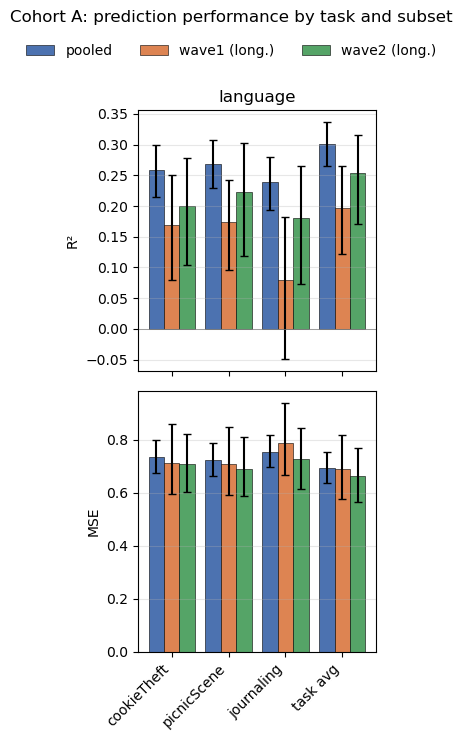

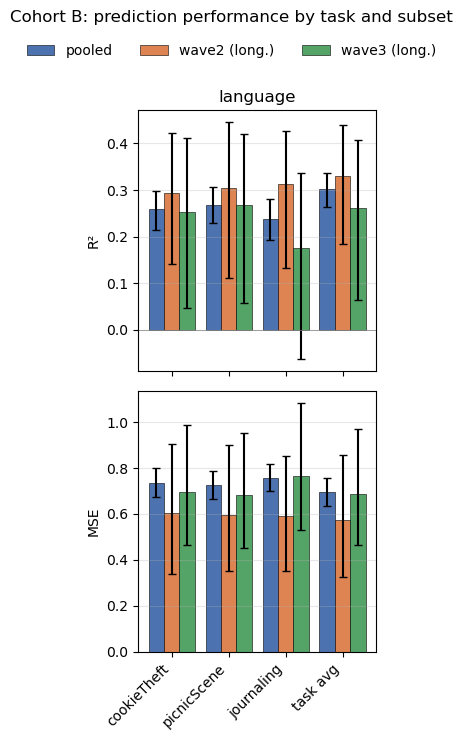

In [112]:
def plot_eval_bars(eval_df, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        2, len(targets),
        figsize=(3.2 * len(targets), 7),
        sharex=True,
    )
    if len(targets) == 1:
        axes = axes.reshape(2, 1)

    task_order = tasks + ['average']
    task_labels = tasks + ['task avg']
    subsets = ['pooled', f'{wave_a}_longitudinal', f'{wave_b}_longitudinal']
    subset_labels = {
        'pooled': 'pooled',
        f'{wave_a}_longitudinal': f'{wave_a} (long.)',
        f'{wave_b}_longitudinal': f'{wave_b} (long.)',
    }
    subset_colors = {
        'pooled': '#4c72b0',
        f'{wave_a}_longitudinal': '#dd8452',
        f'{wave_b}_longitudinal': '#55a467',
    }

    # Filter eval_df to the rows for this cohort + pooled
    cohort_rows = eval_df[(eval_df['cohort'] == label) | (eval_df['cohort'] == '-')]

    x = np.arange(len(task_order))
    width = 0.27

    for metric_idx, metric in enumerate(['r2', 'mse']):
        for col_idx, target in enumerate(targets):
            ax = axes[metric_idx, col_idx]
            for i, subset in enumerate(subsets):
                sub = (cohort_rows[
                    (cohort_rows['target'] == target)
                    & (cohort_rows['subset'] == subset)
                ].set_index('task').loc[task_order])
                y = sub[metric].values
                err_lo = y - sub[f'{metric}_ci_low'].values
                err_hi = sub[f'{metric}_ci_high'].values - y
                offset = (i - 1) * width
                ax.bar(
                    x + offset, y, width, yerr=[err_lo, err_hi],
                    color=subset_colors[subset],
                    label=subset_labels[subset]
                        if (metric_idx == 0 and col_idx == 0) else None,
                    capsize=3, edgecolor='black', linewidth=0.4,
                )
            ax.axhline(0, color='grey', linewidth=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels(task_labels, rotation=45, ha='right')
            ax.grid(axis='y', alpha=0.3)
            if metric_idx == 0:
                ax.set_title(target.replace('_', ' '))
            if col_idx == 0:
                ax.set_ylabel('R²' if metric == 'r2' else 'MSE')

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
    fig.suptitle(
        f'Cohort {label}: prediction performance by task and subset',
        y=1.05,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_eval_bars(eval_df, label, wave_a, wave_b, targets, tasks)

## Test-retest reliability (ICC(3,1))

For each cohort, compute ICC(3,1) between its two waves on:
- the cognitive composite score (target)
- each task's speech-based prediction
- the per-participant cross-task average prediction
- the picture-description average (cookieTheft + picnicScene)

In [113]:
def compute_icc3(df, col_a, col_b, wave_a, wave_b):
    """ICC(3,1) — two-way mixed, consistency, single rater — between two repeated
    measures taken from a wide-format df. Returns (icc, ci_low, ci_high, n).

    Handles both older ('ICC3') and newer ('ICC(C,1)') pingouin Type labels.
    """
    sub = df.loc[:, [col_a, col_b]].dropna()
    ids = sub.index.astype(str).tolist()
    melted = pd.DataFrame({
        'id': ids * 2,
        'wave': [wave_a] * len(sub) + [wave_b] * len(sub),
        'score': np.concatenate([sub[col_a].values, sub[col_b].values]),
    })
    icc = pg.intraclass_corr(
        data=melted, targets='id', raters='wave',
        ratings='score', nan_policy='omit',
    )
    mask = icc['Type'].isin(['ICC3', 'ICC(C,1)'])
    row = icc[mask].iloc[0]
    ci_col = 'CI95%' if 'CI95%' in icc.columns else 'CI95'
    ci_low, ci_high = row[ci_col]
    return row['ICC'], ci_low, ci_high, len(sub)


def build_reliability_df(longitudinal_by_cohort, cohorts, targets, tasks):
    """Long-format df of ICC(3,1) for composite scores and predictions, stacked
    across cohorts with a `cohort` column."""
    rows = []
    for label, wave_a, wave_b in cohorts:
        long_df = longitudinal_by_cohort[label]
        for target in targets:
            # Composite score reliability
            icc, lo, hi, n = compute_icc3(
                long_df,
                (wave_a, target, 'target'),
                (wave_b, target, 'target'),
                wave_a, wave_b,
            )
            rows.append({
                'cohort': label, 'measure': 'composite_score',
                'target': target, 'task': None,
                'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
            })

            # Per-task prediction reliability
            for task in tasks:
                icc, lo, hi, n = compute_icc3(
                    long_df,
                    (wave_a, target, task),
                    (wave_b, target, task),
                    wave_a, wave_b,
                )
                rows.append({
                    'cohort': label, 'measure': 'prediction',
                    'target': target, 'task': task,
                    'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
                })

            # Cross-task average prediction reliability
            avg_a = long_df.loc[:, [(wave_a, target, t) for t in tasks]].mean(axis=1)
            avg_b = long_df.loc[:, [(wave_b, target, t) for t in tasks]].mean(axis=1)
            tmp = pd.DataFrame({'avg_a': avg_a, 'avg_b': avg_b})
            icc, lo, hi, n = compute_icc3(tmp, 'avg_a', 'avg_b', wave_a, wave_b)
            rows.append({
                'cohort': label, 'measure': 'prediction',
                'target': target, 'task': 'average',
                'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
            })

            # picnicScene + cookieTheft (pictureDescription) average
            pd_a = long_df.loc[
                :, [(wave_a, target, t) for t in ['picnicScene', 'cookieTheft']]
            ].mean(axis=1)
            pd_b = long_df.loc[
                :, [(wave_b, target, t) for t in ['picnicScene', 'cookieTheft']]
            ].mean(axis=1)
            tmp = pd.DataFrame({'pd_a': pd_a, 'pd_b': pd_b})
            icc, lo, hi, n = compute_icc3(tmp, 'pd_a', 'pd_b', wave_a, wave_b)
            rows.append({
                'cohort': label, 'measure': 'prediction',
                'target': target, 'task': 'pictureDescription',
                'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
            })
    return pd.DataFrame(rows)

In [114]:
reliability_df = build_reliability_df(longitudinal_by_cohort, COHORTS, targets, tasks)
reliability_df

,cohort,measure,target,task,n,icc,icc_ci_low,icc_ci_high
0,A,composite_score,language,NaN,279,0.684401,0.62,0.74
1,A,prediction,language,cookieTheft,279,0.665846,0.60,0.73
2,A,prediction,language,picnicScene,279,0.735676,0.68,0.79
3,A,prediction,language,journaling,279,0.543895,0.46,0.62
4,A,prediction,language,average,279,0.785530,0.74,0.83
5,A,prediction,language,pictureDescription,279,0.789212,0.74,0.83
6,B,composite_score,language,NaN,69,0.718331,0.58,0.82
7,B,prediction,language,cookieTheft,69,0.826771,0.73,0.89
8,B,prediction,language,picnicScene,69,0.867931,0.80,0.92
9,B,prediction,language,journaling,69,0.769553,0.65,0.85


In [115]:
# Wide views: one row per (cohort, target), columns show composite + each task + averages.
_rel = reliability_df.copy()
_rel['icc_str'] = _rel.apply(
    lambda r: f"{r['icc']:.2f} [{r['icc_ci_low']:.2f}, {r['icc_ci_high']:.2f}]", axis=1
)
_rel['col'] = _rel['measure'].where(_rel['measure'] == 'composite_score', _rel['task'])
reliability_wide = _rel.pivot_table(
    index=['cohort', 'target'], columns='col', values='icc_str', aggfunc='first',
)
ordered_cols = ['composite_score'] + tasks + ['average']#, 'pictureDescription']
reliability_wide = reliability_wide.loc[
    :, [c for c in ordered_cols if c in reliability_wide.columns]
]
reliability_wide

,col,composite_score,cookieTheft,picnicScene,journaling,average
cohort,target,,,,,
A,language,"0.68 [0.62, 0.74]","0.67 [0.60, 0.73]","0.74 [0.68, 0.79]","0.54 [0.46, 0.62]","0.79 [0.74, 0.83]"
B,language,"0.72 [0.58, 0.82]","0.83 [0.73, 0.89]","0.87 [0.80, 0.92]","0.77 [0.65, 0.85]","0.91 [0.85, 0.94]"


In [116]:
def emit_reliability_table(reliability_wide, target, label, wave_a, wave_b):
    table = reliability_wide.loc[(label, target), :].rename(
        index={
            'composite_score': f'Cognitive composite score (\\textit{{{target}}})',
            'cookieTheft': 'Predictions: Cookie Theft',
            'picnicScene': 'Predictions: Picnic Scene',
            'journaling': 'Predictions: Journaling',
            'average': 'Predictions: Avg. Prediction',
            'pictureDescription': 'Predictions: Avg. Picture Desc.',
        },
    ).reset_index()
    table = table.rename(columns={target: 'ICC [95\\% CI]', 'col': ''})

    print(table.to_latex(
        float_format='%.2f',
        column_format='l' + 'c' * len(table.columns),
        index=False,
        caption=(
            f"Test-retest reliability (ICC) of the \\textit{{{target}}} "
            f"cognitive composite score and the speech-based predictions between "
            f"baseline and follow-up (Cohort {label}). We report point estimates "
            f"with 95\\% bootstrap CI."
        ),
        label=f'tab:reliability_cohort{label}',
    ))


for target in targets:
    for label, wave_a, wave_b in COHORTS:
        print(f'\n% === Reliability — target={target}, Cohort {label} ({now()}) ===')
        emit_reliability_table(reliability_wide, target, label, wave_a, wave_b)


% === Reliability — target=language, Cohort A (2026-06-02 13:13) ===
\begin{table}
\caption{Test-retest reliability (ICC) of the \textit{language} cognitive composite score and the speech-based predictions between baseline and follow-up (Cohort A). We report point estimates with 95\% bootstrap CI.}
\label{tab:reliability_cohortA}
\begin{tabular}{lcc}
\toprule
 & A \\
 & ICC [95\% CI] \\
\midrule
Cognitive composite score (\textit{language}) & 0.68 [0.62, 0.74] \\
Predictions: Cookie Theft & 0.67 [0.60, 0.73] \\
Predictions: Picnic Scene & 0.74 [0.68, 0.79] \\
Predictions: Journaling & 0.54 [0.46, 0.62] \\
Predictions: Avg. Prediction & 0.79 [0.74, 0.83] \\
\bottomrule
\end{tabular}
\end{table}


% === Reliability — target=language, Cohort B (2026-06-02 13:13) ===
\begin{table}
\caption{Test-retest reliability (ICC) of the \textit{language} cognitive composite score and the speech-based predictions between baseline and follow-up (Cohort B). We report point estimates with 95\% bootstrap

In [117]:
def emit_reliability_table(reliability_wide, targets, label, wave_a, wave_b):
    pieces = []
    for target in targets:
        col = reliability_wide.loc[(label, target), :]
        pieces.append(col.rename(f'\\textit{{{rename_target(target)}}}'))
    table = pd.concat(pieces, axis=1)

    row_rename = {
        'composite_score': 'Cognitive composite score',
        'cookieTheft': 'Predictions: Cookie Theft',
        'picnicScene': 'Predictions: Picnic Scene',
        'journaling': 'Predictions: Journaling',
        'average': 'Predictions: Avg. Prediction',
        'pictureDescription': 'Predictions: Avg. Picture Desc.',
    }
    table = table.rename(index=row_rename).reset_index().rename(columns={'col': ''})

    targets_str = ', '.join(f'\\textit{{{rename_target(t)}}}' for t in targets)
    print(table.to_latex(
        float_format='%.2f',
        column_format='l' + 'c' * (len(table.columns) - 1),
        index=False,
        caption=(
            f"Test-retest reliability (ICC) of the cognitive composite scores "
            f"({targets_str}) and the speech-based predictions between "
            f"{wave_a} and {wave_b} (Cohort {label}). Point estimates with "
            f"95\\% bootstrap CI."
        ),
        label=f's_tab:reliability_cohort{label}',
    ))


for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Reliability — Cohort {label} ({now()}) ===')
    emit_reliability_table(reliability_wide, targets, label, wave_a, wave_b)


% === Reliability — Cohort A (2026-06-02 13:13) ===
\begin{table}
\caption{Test-retest reliability (ICC) of the cognitive composite scores (\textit{Language}) and the speech-based predictions between wave1 and wave2 (Cohort A). Point estimates with 95\% bootstrap CI.}
\label{s_tab:reliability_cohortA}
\begin{tabular}{lc}
\toprule
 & \textit{Language} \\
\midrule
Cognitive composite score & 0.68 [0.62, 0.74] \\
Predictions: Cookie Theft & 0.67 [0.60, 0.73] \\
Predictions: Picnic Scene & 0.74 [0.68, 0.79] \\
Predictions: Journaling & 0.54 [0.46, 0.62] \\
Predictions: Avg. Prediction & 0.79 [0.74, 0.83] \\
\bottomrule
\end{tabular}
\end{table}


% === Reliability — Cohort B (2026-06-02 13:13) ===
\begin{table}
\caption{Test-retest reliability (ICC) of the cognitive composite scores (\textit{Language}) and the speech-based predictions between wave2 and wave3 (Cohort B). Point estimates with 95\% bootstrap CI.}
\label{s_tab:reliability_cohortB}
\begin{tabular}{lc}
\toprule
 & \textit{Langu

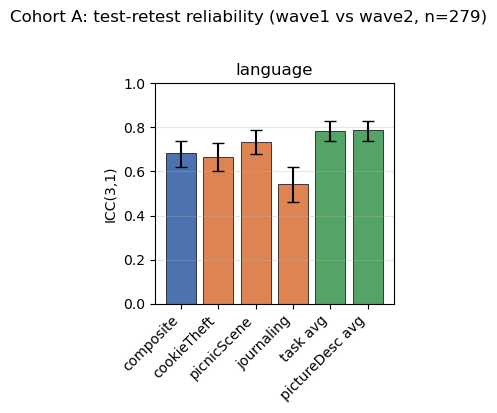

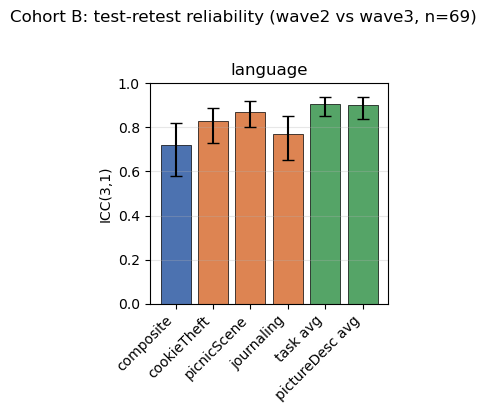

In [118]:
def plot_reliability_bars(reliability_df, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        1, len(targets),
        figsize=(3.2 * len(targets), 4),
        sharey=True,
    )
    if not isinstance(axes, Iterable):
        axes = [axes]

    col_order = ['composite_score'] + tasks + ['average', 'pictureDescription']
    col_labels = ['composite'] + tasks + ['task avg', 'pictureDesc avg']

    sample_sizes = []
    cohort_rows = reliability_df[reliability_df['cohort'] == label]
    for ax, target in zip(axes, targets):
        sub = cohort_rows[cohort_rows['target'] == target].copy()
        n = sub['n'].to_list()
        sample_sizes.extend(n)
        sub['col'] = sub['measure'].where(sub['measure'] == 'composite_score', sub['task'])
        sub = sub.set_index('col').loc[col_order]

        x = np.arange(len(col_order))
        y = sub['icc'].values
        err_lo = y - sub['icc_ci_low'].values
        err_hi = sub['icc_ci_high'].values - y

        colors = ['#4c72b0'] + ['#dd8452'] * len(tasks) + ['#55a467', '#55a467']
        ax.bar(
            x, y, yerr=[err_lo, err_hi], color=colors, capsize=4,
            edgecolor='black', linewidth=0.5,
        )
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(col_labels, rotation=45, ha='right')
        ax.set_title(target.replace('_', ' '))
        ax.set_ylim(min(0, sub['icc_ci_low'].min() - 0.05), 1.0)
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('ICC(3,1)')
    sample_sizes_text = (
        list(set(sample_sizes))[0] if len(set(sample_sizes)) == 1
        else f"{sample_sizes}"
    )
    fig.suptitle(
        f'Cohort {label}: test-retest reliability '
        f'({wave_a} vs {wave_b}, n={sample_sizes_text})',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_reliability_bars(reliability_df, label, wave_a, wave_b, targets, tasks)

In [119]:
# test-retest reliability of picnicScene vs cookieTheft predictions
# using ICC(3,1)
# (crosssectional data + combined waves within each cohort)

import pingouin as pg

rows = []

def compute_icc_across_tasks(x, y):
    df_icc = pd.DataFrame({
        'subject': range(len(x)),
        'cookieTheft': x.values,
        'picnicScene': y.values,
    })

    long_icc = df_icc.melt(
        id_vars='subject',
        var_name='rater',
        value_name='score'
    )

    icc_table = pg.intraclass_corr(
        data=long_icc,
        targets='subject',
        raters='rater',
        ratings='score'
    )

    icc31 = icc_table[icc_table['Type'] == 'ICC3'].iloc[0]

    return icc31['ICC'], icc31['CI95']


# ------------------------------------------------------------------
# Cross-sectional agreement between picture-description tasks
# ------------------------------------------------------------------

for target in targets:
    x = crosssectional[(target, 'cookieTheft')]
    y = crosssectional[(target, 'picnicScene')]

    mask = x.notna() & y.notna()

    icc, ci95 = compute_icc_across_tasks(
        x[mask].reset_index(drop=True),
        y[mask].reset_index(drop=True)
    )

    rows.append({
        'target': target,
        'Cohort': f'Entire data',
        '\\# Observations': int(mask.sum()),
        'ICC [95\\% CI]': f'{icc:.2f} [{ci95[0]:.2f}, {ci95[1]:.2f}]',
    })


# ------------------------------------------------------------------
# Combined waves within each cohort
# ------------------------------------------------------------------

for label, wave_a, wave_b in COHORTS:
    long_df = longitudinal_by_cohort[label]

    for target in targets:

        x = pd.concat([
            long_df[(wave_a, target, 'cookieTheft')],
            long_df[(wave_b, target, 'cookieTheft')],
        ], ignore_index=True)

        y = pd.concat([
            long_df[(wave_a, target, 'picnicScene')],
            long_df[(wave_b, target, 'picnicScene')],
        ], ignore_index=True)

        mask = x.notna() & y.notna()

        icc, ci95 = compute_icc_across_tasks(
            x[mask].reset_index(drop=True),
            y[mask].reset_index(drop=True)
        )

        rows.append({
            'target': target,
            'Cohort': f"Cohort {label}",
            '\\# Observations': int(mask.sum()),
            'ICC [95\\% CI]': f'{icc:.2f} [{ci95[0]:.2f}, {ci95[1]:.2f}]',
        })


picnic_vs_cookie_reliability_df = pd.DataFrame(rows).query("target == 'language'").drop(columns=['target'])

picnic_vs_cookie_reliability_df

,Cohort,\# Observations,ICC [95\% CI]
0,Entire data,1432,"0.81 [0.79, 0.83]"
1,Cohort A,584,"0.75 [0.72, 0.79]"
2,Cohort B,139,"0.87 [0.82, 0.90]"


In [120]:
picnic_vs_cookie_reliability_latex = picnic_vs_cookie_reliability_df.to_latex(
    index=False,
    column_format='l' * (len(picnic_vs_cookie_reliability_df.columns)),
    caption=(
        "Test-retest reliability (ICC) comparing the Cookie Theft and Picnic Scene speech predictions of the same participant at the same data wave. Results are given for the \\textit{language} composite cognitive score, and computed across the entire data set and within each cohort. We report point estimates with 95\\% bootstrap CI."
    ),
    label='tab:picnic_cookie_reliability',)
print(f"% === Test retest cookieTheft vs. picnicScene ({now()}) ===")
print(picnic_vs_cookie_reliability_latex)

% === Test retest cookieTheft vs. picnicScene (2026-06-02 13:13) ===
\begin{table}
\caption{Test-retest reliability (ICC) comparing the Cookie Theft and Picnic Scene speech predictions of the same participant at the same data wave. Results are given for the \textit{language} composite cognitive score, and computed across the entire data set and within each cohort. We report point estimates with 95\% bootstrap CI.}
\label{tab:picnic_cookie_reliability}
\begin{tabular}{lll}
\toprule
Cohort & \# Observations & ICC [95\% CI] \\
\midrule
Entire data & 1432 & 0.81 [0.79, 0.83] \\
Cohort A & 584 & 0.75 [0.72, 0.79] \\
Cohort B & 139 & 0.87 [0.82, 0.90] \\
\bottomrule
\end{tabular}
\end{table}



In [121]:
# Longitudinal change in prediction scores across waves within each cohort
# Per task + averaged prediction across tasks
# Single combined summary table


from scipy.stats import ttest_rel

rows = []
TASKS = ['cookieTheft', 'picnicScene', 'journaling']
for label, wave_a, wave_b in COHORTS:
    long_df = longitudinal_by_cohort[label]
    for target in targets:
        score_sets = {
            task: (
                long_df[(wave_a, target, task)],
                long_df[(wave_b, target, task)],
            )
            for task in TASKS
        }
        score_sets['average_prediction'] = (
            pd.concat([v[0] for v in score_sets.values()], axis=1).mean(axis=1),
            pd.concat([v[1] for v in score_sets.values()], axis=1).mean(axis=1),
        )
        for task, (x, y) in score_sets.items():
            mask = x.notna() & y.notna()
            x, y = x[mask], y[mask]
            diff = y - x
            _, pval = ttest_rel(y, x)
            rows.append({
                'Cognitive domain': rename_target(target),
                'Cohort': f"Cohort {label}",
                'Task': rename_tasks.get(task,task),
                "Baseline": f'{x.mean():.2f} $\\pm$ {x.std():.2f}',
                "Follow-up": f'{y.mean():.2f} $\\pm$ {y.std():.2f}',
                '% Improv. / % Decline':
                    f'{(diff > 0).mean()*100:.1f}% / {(diff < 0).mean()*100:.1f}%',
                'Difference':
                    f'{diff.mean():.2f} $\\pm$ {diff.std():.2f}',
                'p-val': f'{pval:.2g}',
            })

#longitudinal_prediction_summary_df = pd.DataFrame(rows)#.query("target == 'language'").drop(columns=['target'])
longitudinal_prediction_summary_df = pd.DataFrame(rows).query("Cohort == 'Cohort B'").drop(columns=['Cohort'])
#longitudinal_prediction_summary_df = longitudinal_prediction_summary_df.set_index("Cognitive domain")
longitudinal_prediction_summary_df


,Cognitive domain,Task,Baseline,Follow-up,% Improv. / % Decline,Difference,p-val
4,Language,Cookie Theft,0.38 $\pm$ 0.41,0.39 $\pm$ 0.42,50.7% / 49.3%,0.01 $\pm$ 0.24,0.84
5,Language,Picnic Scene,0.30 $\pm$ 0.44,0.31 $\pm$ 0.44,50.7% / 49.3%,0.01 $\pm$ 0.22,0.63
6,Language,Journaling,0.36 $\pm$ 0.43,0.37 $\pm$ 0.46,58.0% / 42.0%,0.01 $\pm$ 0.30,0.72
7,Language,Avg. Prediction,0.35 $\pm$ 0.40,0.36 $\pm$ 0.41,56.5% / 43.5%,0.01 $\pm$ 0.17,0.61


In [122]:

longitudinal_prediction_summary_latex = longitudinal_prediction_summary_df.to_latex(
    index=False,
    column_format='l' * (len(longitudinal_prediction_summary_df.columns)),
    caption=(
        "Longitudinal change in speech-based predictions across assessments within each cohort. We compare the baseline and follow-up assessment of the same participants in the two cohorts, testing for significant differences with paired $t$-tests. Results are given for Cohort B, and computed separately for each task's predictions and the average prediction across tasks."
    ),
    label='tab:longitudinal_prediction_change_cohortB',).replace("%", "\\%")
print(f"% === Longitudinal change in prediction scores ({now()}) ===")
print(longitudinal_prediction_summary_latex)

% === Longitudinal change in prediction scores (2026-06-02 13:13) ===
\begin{table}
\caption{Longitudinal change in speech-based predictions across assessments within each cohort. We compare the baseline and follow-up assessment of the same participants in the two cohorts, testing for significant differences with paired $t$-tests. Results are given for Cohort B, and computed separately for each task's predictions and the average prediction across tasks.}
\label{tab:longitudinal_prediction_change_cohortB}
\begin{tabular}{lllllll}
\toprule
Cognitive domain & Task & Baseline & Follow-up & \% Improv. / \% Decline & Difference & p-val \\
\midrule
Language & Cookie Theft & 0.38 $\pm$ 0.41 & 0.39 $\pm$ 0.42 & 50.7\% / 49.3\% & 0.01 $\pm$ 0.24 & 0.84 \\
Language & Picnic Scene & 0.30 $\pm$ 0.44 & 0.31 $\pm$ 0.44 & 50.7\% / 49.3\% & 0.01 $\pm$ 0.22 & 0.63 \\
Language & Journaling & 0.36 $\pm$ 0.43 & 0.37 $\pm$ 0.46 & 58.0\% / 42.0\% & 0.01 $\pm$ 0.30 & 0.72 \\
Language & Avg. Prediction & 0.35 